In [ ]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
df = pd.read_csv("CrimesOnWomenData.csv")
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [ ]:
df['State'] = df['State'].str.upper().str.strip()

In [ ]:
df.isnull().sum()

Unnamed: 0    0
State         0
Year          0
Rape          0
K&A           0
DD            0
AoW           0
AoM           0
DV            0
WT            0
dtype: int64

In [ ]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  736 non-null    int64 
 1   State       736 non-null    object
 2   Year        736 non-null    int64 
 3   Rape        736 non-null    int64 
 4   K&A         736 non-null    int64 
 5   DD          736 non-null    int64 
 6   AoW         736 non-null    int64 
 7   AoM         736 non-null    int64 
 8   DV          736 non-null    int64 
 9   WT          736 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 57.6+ KB


In [ ]:
df.rename(columns={
    'K&A': 'Kidnapping',
    'DD': 'Dowry_Deaths',
    'AoW': 'Assault_Women',
    'AoM': 'Assault_Minors',
    'DV': 'Domestic_Violence',
    'WT': 'Trafficking'
}, inplace=True)

In [ ]:
df['Total_Crime'] = df[
    ['Rape', 'Kidnapping', 'Dowry_Deaths',
     'Assault_Women', 'Assault_Minors',
     'Domestic_Violence', 'Trafficking']
].sum(axis=1)

In [ ]:
df.head

<bound method NDFrame.head of      Unnamed: 0              State  Year  Rape  Kidnapping  Dowry_Deaths  \
0             0     ANDHRA PRADESH  2001   871         765           420   
1             1  ARUNACHAL PRADESH  2001    33          55             0   
2             2              ASSAM  2001   817        1070            59   
3             3              BIHAR  2001   888         518           859   
4             4       CHHATTISGARH  2001   959         171            70   
..          ...                ...   ...   ...         ...           ...   
731         731         D&N HAVELI  2021  1250        4083           141   
732         732        DAMAN & DIU  2021   315         904            16   
733         733           DELHI UT  2021     2           1             0   
734         734        LAKSHADWEEP  2021     0           0             0   
735         735         PUDUCHERRY  2021     2           0             2   

     Assault_Women  Assault_Minors  Domestic_Violence  Tr

In [ ]:
top5_states = df.groupby('State')['Total_Crime'].sum().sort_values(ascending=False).head(5)

top5_states

State
UTTAR PRADESH     529734
MADHYA PRADESH    413157
WEST BENGAL       409242
ANDHRA PRADESH    391123
RAJASTHAN         379264
Name: Total_Crime, dtype: int64

In [ ]:
top5_list = top5_states.index

df_top5 = df[df['State'].isin(top5_list)]

In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


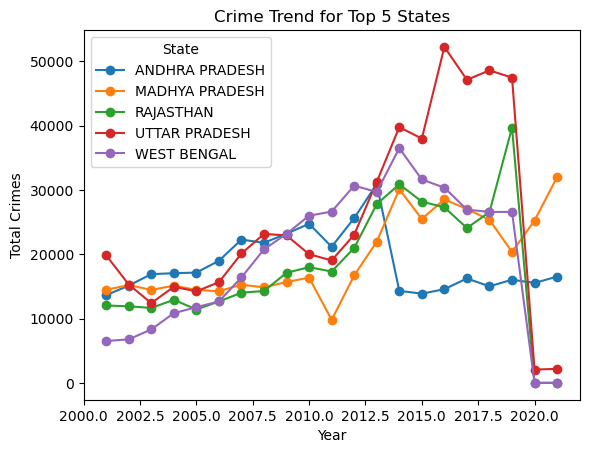

In [ ]:
import matplotlib.pyplot as plt

trend_top5 = df_top5.groupby(['Year', 'State'])['Total_Crime'].sum().unstack()

trend_top5.plot(marker='o')
plt.title("Crime Trend for Top 5 States")
plt.ylabel("Total Crimes")
plt.show()

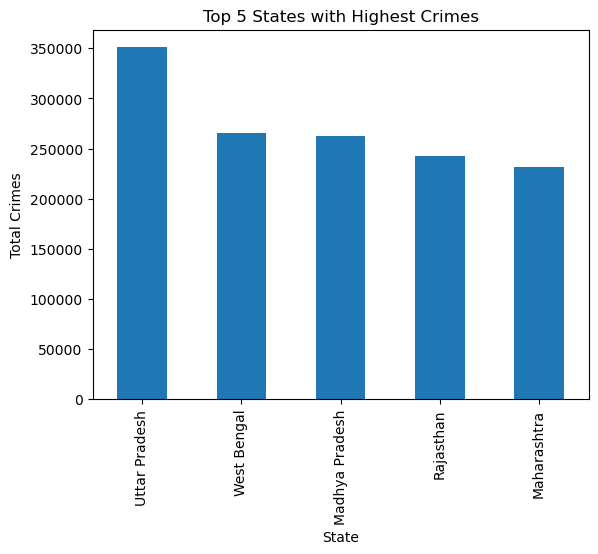

In [ ]:
top5_states.plot(kind='bar')
plt.title("Top 5 States with Highest Crimes")
plt.ylabel("Total Crimes")
plt.show()

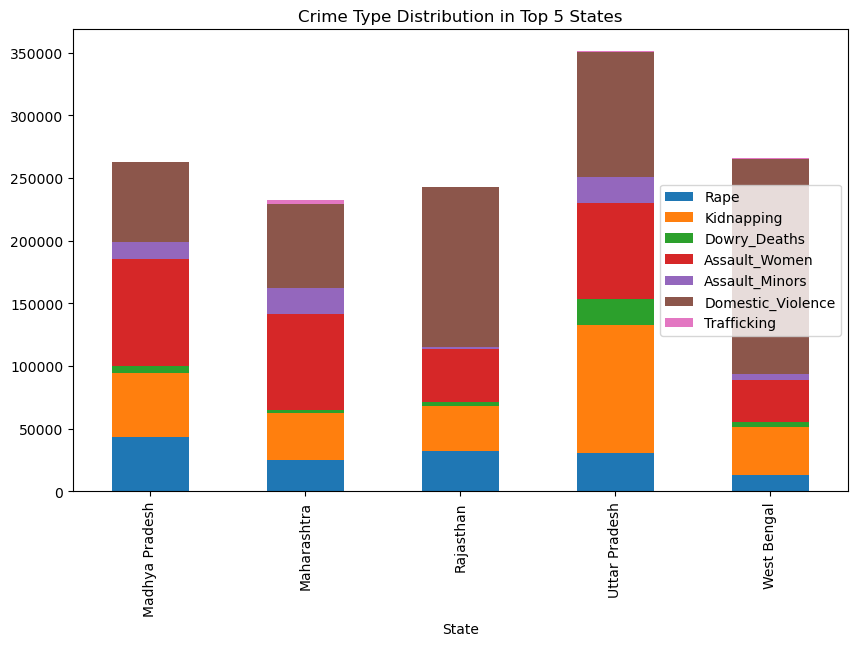

In [ ]:
crime_types = ['Rape', 'Kidnapping', 'Dowry_Deaths',
               'Assault_Women', 'Assault_Minors',
               'Domestic_Violence', 'Trafficking']

df_top5.groupby('State')[crime_types].sum().plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Crime Type Distribution in Top 5 States")
plt.show()

In [ ]:
growth_top5 = trend_top5.pct_change().mean() * 100
print(growth_top5)

State
Madhya Pradesh    15.486635
Maharashtra        3.944500
Rajasthan         -3.017092
Uttar Pradesh      1.790401
West Bengal        4.849694
dtype: float64


In [ ]:
df_top5.groupby('State')[crime_types].sum().idxmax(axis=1)

State
Madhya Pradesh        Assault_Women
Maharashtra           Assault_Women
Rajasthan         Domestic_Violence
Uttar Pradesh            Kidnapping
West Bengal       Domestic_Violence
dtype: object

In [ ]:
crime_growth = df.groupby('Year')[crime_types].sum().pct_change().mean() * 100
crime_growth.sort_values(ascending=False)

Assault_Women               inf
Trafficking          329.022380
Kidnapping             9.496725
Domestic_Violence      5.638216
Rape                   4.109057
Assault_Minors         3.484063
Dowry_Deaths           0.443694
dtype: float64

In [ ]:
crime_totals = df[crime_types].sum()
crime_percent = (crime_totals / crime_totals.sum()) * 100
crime_percent

Rape                 11.005189
Kidnapping           17.154287
Dowry_Deaths          3.261279
Assault_Women        23.876240
Assault_Minors        5.030772
Domestic_Violence    39.237615
Trafficking           0.434618
dtype: float64

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


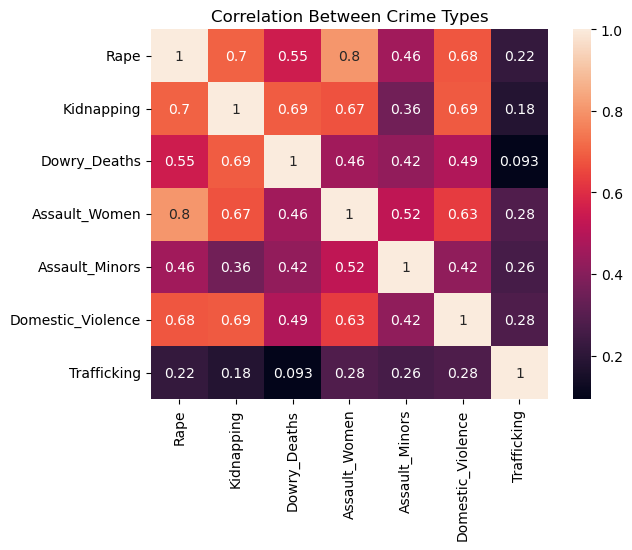

In [ ]:
import seaborn as sns

sns.heatmap(df[crime_types].corr(), annot=True)
plt.title("Correlation Between Crime Types")
plt.show()

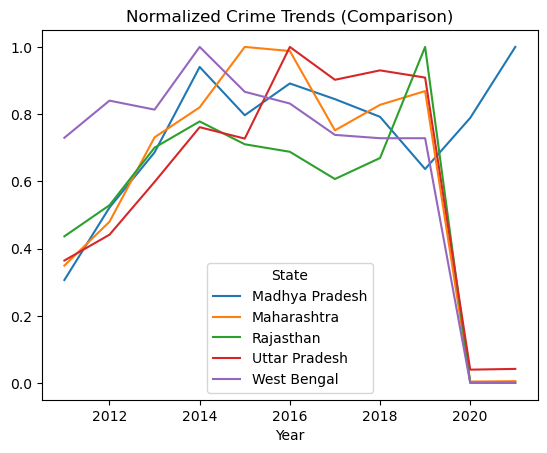

In [ ]:
normalized = trend_top5 / trend_top5.max()
normalized.plot()
plt.title("Normalized Crime Trends (Comparison)")
plt.show()

In [ ]:
df_top5.groupby('State')['Total_Crime'].std()

State
Madhya Pradesh     6390.038283
Maharashtra       12270.537913
Rajasthan         12271.559921
Uttar Pradesh     18111.643926
West Bengal       12288.412331
Name: Total_Crime, dtype: float64

In [ ]:
improvement = trend_top5.iloc[-1] - trend_top5.iloc[0]
improvement.sort_values()

State
West Bengal      -26596
Rajasthan        -17306
Uttar Pradesh    -16844
Maharashtra      -11691
Madhya Pradesh    22200
dtype: int64